In [59]:
import warnings


warnings.filterwarnings("ignore")  # avoid printing out absolute paths

In [2]:
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)


In [3]:
file_path = 'data-from-other-repo/'
co2_emissions = pd.read_csv(file_path + 'annual-co2-emissions-per-country/annual-co2-emissions-per-country.csv')
co2_emission_index = np.where(np.array((co2_emissions['Entity'])=='World'))
world_co2_emission = co2_emissions.iloc[int(min(co2_emission_index[0])):int(max(co2_emission_index[0]))+1]
world_co2_emission= world_co2_emission.drop('Code',axis=1)

world_co2_emission

,Entity,Year,Annual CO₂ emissions
28837,World,1750,9.305937e+06
28838,World,1751,9.407229e+06
28839,World,1752,9.505168e+06
28840,World,1753,9.610490e+06
28841,World,1754,9.733580e+06
...,...,...,...
29107,World,2020,3.515823e+10
29108,World,2021,3.686686e+10
29109,World,2022,3.752777e+10
29110,World,2023,3.809404e+10


In [20]:
from pytorch_forecasting import TimeSeriesDataSet

max_prediction_length = 6
max_encoder_length = 24
training_cutoff = world_co2_emission["Year"].max() - max_prediction_length


# create the dataset from the pandas dataframe
training = TimeSeriesDataSet(
    world_co2_emission[lambda x: x.Year <= training_cutoff],
    group_ids=["Entity"],
    target="Annual CO₂ emissions",
    time_idx="Year",
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    time_varying_unknown_reals=["Annual CO₂ emissions"],
)

In [21]:

# create validation set (predict=True) which means to predict the last max_prediction_length points in time
# for each series
validation = TimeSeriesDataSet.from_dataset(
    training, world_co2_emission, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = 10  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=0
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=0
)

In [22]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# calculate baseline mean absolute error, i.e. predict next value as the last available value from the history
baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
MAE()(baseline_predictions.output.to(device), baseline_predictions.y)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


tensor(1.0133e+09, device='mps:0')

In [23]:
# configure network and trainer
pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cpu",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.03,
    hidden_size=8,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=QuantileLoss(),
    optimizer="ranger",
    # reduce learning rate if no improvement in validation loss after x epochs
    # reduce_on_plateau_patience=1000,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 4.2k


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
Finding best initial lr:  96%|█████████▌| 96/100 [00:01<00:00, 57.54it/s]
LR finder stopped early after 96 steps due to diverging loss.
Restoring states from the checkpoint path at /Users/weronika/Library/CloudStorage/OneDrive-UniversityofLeeds/Documents/climate-data-hackathon/.lr_find_d1d5aac0-6a6d-493e-936d-e99b3c20c8f6.ckpt
Restored all states from the checkpoint at /Users/weronika/Library/CloudStorage/OneDrive-UniversityofLeeds/Documents/climate-data-hackathon/.lr_find_d1d5aac0-6a6d-493e-936d-e99b3c20c8f6.ckpt
Learning rate set to 5.888436553555889e-06


suggested learning rate: 5.888436553555889e-06


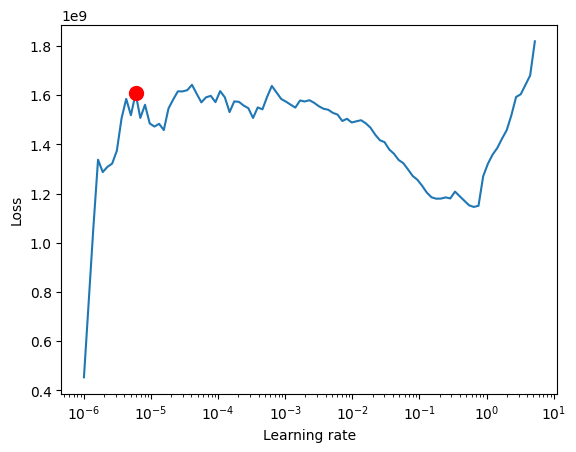

In [24]:
from pytorch_forecasting.tuning import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-6,
)

print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()

In [25]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # comment in for training, running validation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 14.5k


In [26]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 16     | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 528    | train | 0 

Epoch 49: 100%|██████████| 25/25 [00:00<00:00, 41.27it/s, v_num=3, train_loss_step=4.34e+8, val_loss=1.84e+9, train_loss_epoch=2.56e+8]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 25/25 [00:00<00:00, 40.38it/s, v_num=3, train_loss_step=4.34e+8, val_loss=1.84e+9, train_loss_epoch=2.56e+8]


            Hyperparameters

In [27]:
import pickle

from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=30,
    max_epochs=50,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=30),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)

[I 2026-03-30 15:01:19,557] A new study created in memory with name: no-name-4a82586b-553a-45df-84f3-7479cc4c9412
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=50` reached.
[I 2026-03-30 15:02:27,592] Trial 0 finished with value: 651965504.0 and parameters: {'gradient_clip_val': 0.05334434153581866, 'hidden_size': 106, 'dropout': 0.1601852113278603, 'hidden_continuous_size': 94, 'attention_head_size': 1, 'learning_rate': 0.0031513106577459346}. Best is trial 0 with value: 651965504.0.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable 

{'gradient_clip_val': 0.7183026803987631, 'hidden_size': 109, 'dropout': 0.1998163400073291, 'hidden_continuous_size': 95, 'attention_head_size': 3, 'learning_rate': 0.0011796946324859057}


In [28]:
# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="cpu",
    enable_model_summary=True,
    gradient_clip_val=0.7183026803987631,
    limit_train_batches=50,  # comment in for training, running validation every 30 batches
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.02345465741572323,
    hidden_size=109,
    attention_head_size=3,
    dropout=0.1998163400073291,
    hidden_continuous_size=95,
    loss=QuantileLoss(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="ranger",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 637.7k


In [29]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 190    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 39.9 K | train | 0 

Epoch 11: 100%|██████████| 25/25 [00:01<00:00, 23.24it/s, v_num=4, train_loss_step=1.08e+8, val_loss=1.34e+9, train_loss_epoch=2.31e+8]


In [30]:
# load the best model according to the validation loss
# (given that we use early stopping, this is not necessarily the last epoch)
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [31]:
# calculate mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="cpu")
)
MAE()(predictions.output, predictions.y)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


tensor(2.9419e+09)

In [61]:
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs=dict(accelerator="cpu")
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


In [78]:
year_predicting_ = [1987,1992,1997,2005,2015]
for year_predicting in year_predicting_:
    raw_prediction = best_tft.predict(
        training.filter(lambda x: x.time_idx_first_prediction >= year_predicting),
        mode="raw",
        return_x=True,
        trainer_kwargs=dict(accelerator="cpu"),
    )

    # predictions dict keys and structure
    predictions = raw_prediction.output['prediction']  # main predictions tensor

    # extract numpy arrays
    pred_np = predictions.detach().cpu().numpy()  # shape: (batch, horizon, targets)
    np.save('processed_data/Carbon_data_prediction_'+str(max_prediction_length)+'_yrs_backwards_'+str(year_predicting),pred_np)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with 

In [80]:
pred_np.shape

(4, 4, 7)

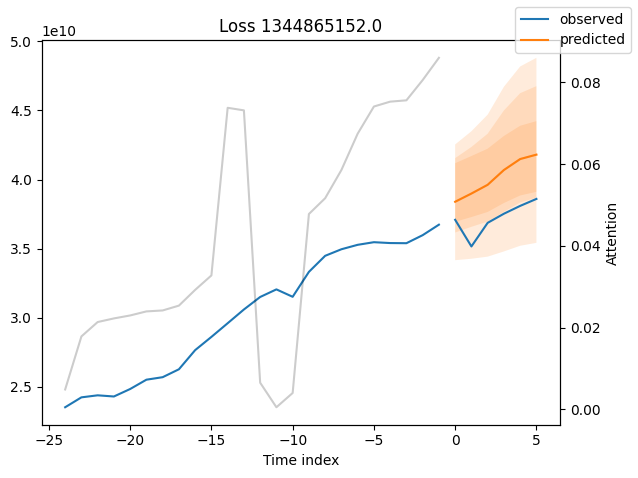

In [33]:
for idx in range(1):  # plot 10 examples
    best_tft.plot_prediction(
        raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True
    )

In [34]:
# select last 24 months from data (max_encoder_length is 24)
encoder_data = world_co2_emission[lambda x: x.Year > x.Year.max() - max_encoder_length]


# select last known data point and create decoder data from it by repeating it and incrementing the month
# in a real world dataset, we should not just forward fill the covariates but specify them to account
# for changes in special days and prices (which you absolutely should do but we are too lazy here)
last_data = world_co2_emission[lambda x: x.Year == x.Year.max()]
decoder_data = pd.concat(
    [
        last_data.assign(Year=lambda x: x.Year + i)
        for i in range(1, max_prediction_length + 1)
    ],
    ignore_index=True,
)

# # add time index consistent with "data"
# decoder_data["time_idx"] = (
#     decoder_data["date"].dt.year * 12 + decoder_data["date"].dt.month
# )
decoder_data["Year"] += (
    encoder_data["Year"].max() + 1 - decoder_data["Year"].min()
)

# # adjust additional time feature(s)
# decoder_data["month"] = decoder_data.date.dt.month.astype(str).astype(
#     "category"
# )  # categories have be strings

# # combine encoder and decoder data
new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


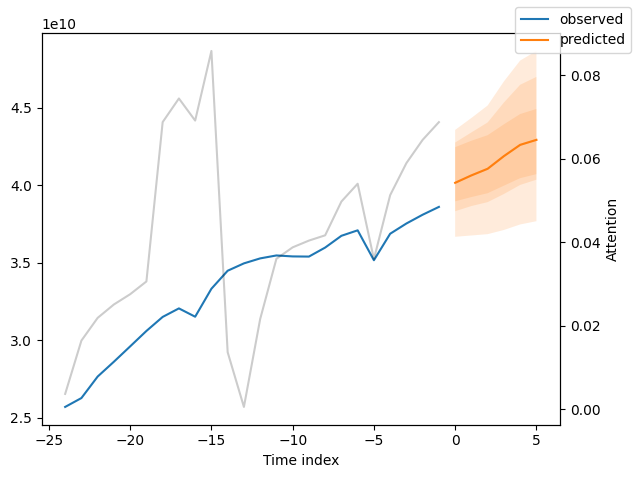

In [35]:
new_raw_predictions = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
)

for idx in range(1):  # plot 10 examples
    best_tft.plot_prediction(
        new_raw_predictions.x,
        new_raw_predictions.output,
        idx=idx,
        show_future_observed=False,
    )

In [ ]:
# predictions dict keys and structure
print(new_raw_predictions.output.keys())  # e.g. ['prediction', 'attention']
predictions = new_raw_predictions.output['prediction']  # main predictions tensor

# extract numpy arrays
pred_np = predictions.detach().cpu().numpy()  # shape: (batch, horizon, targets)
#x_np = {k: v.detach().cpu().numpy() for k, v in new_raw_predictions.x.items()}

# example: first sample's predictions over time horizon
#first_sample_preds = pred_np[0]  # shape: (prediction_length, output_size)

('prediction', 'encoder_attention', 'decoder_attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'decoder_lengths', 'encoder_lengths')


In [39]:
np.save('processed_data/Carbon_data_prediction_'+str(max_prediction_length)+'_yrs',pred_np)